In [1]:
%load_ext autoreload
%autoreload 2
import torch
import sys
from torch_dct3d import DCT3D
from torch_idct3d import IDCT3D

sys.path.append("..")
from src import *

Cupy Available= 1


In [2]:
x = Recording(f"dataset/synthetic/x.tif", max_frames=300).normalized
y = Recording(f"dataset/synthetic/deepcad_15.tif", max_frames=300).normalized

In [3]:
dct=DCT3D()
idct=IDCT3D()

In [13]:
X=dct(torch.tensor(y))

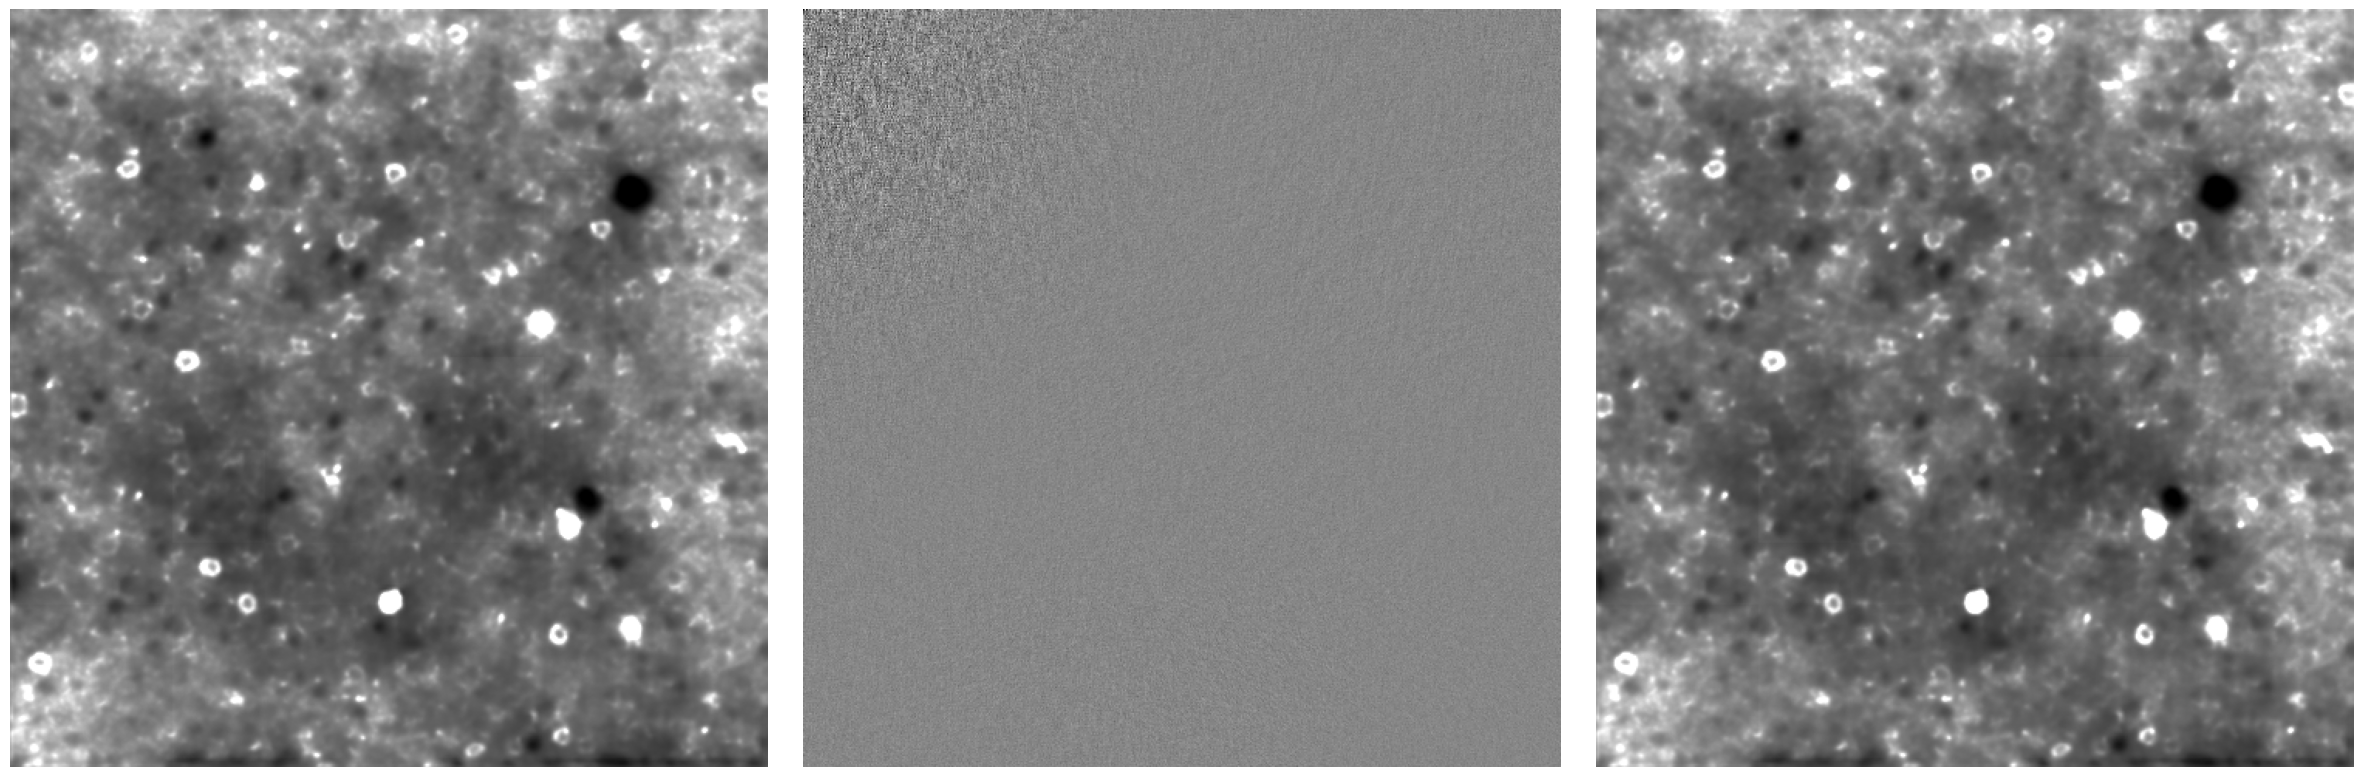

In [18]:
imshow([y[200], X.numpy()[200], idct(X).numpy()[200]], size=8)

In [2]:
s0, δs, t0, δt = 36, 72, -6, 16
W_s = np.clip(
    (np.sqrt(np.arange(512)[None, :] ** 2 + np.arange(512)[:, None] ** 2) - (s0 - δs))
    / (2 * δs),
    0,
    1,
)
W_t = 1 - np.clip((np.arange(1024) - (t0 - δt)) / (2 * δt), 0, 1)
W = (W_s[:, :, None] * W_t).transpose(2, 0, 1)

In [5]:
W.shape

(1024, 512, 512)

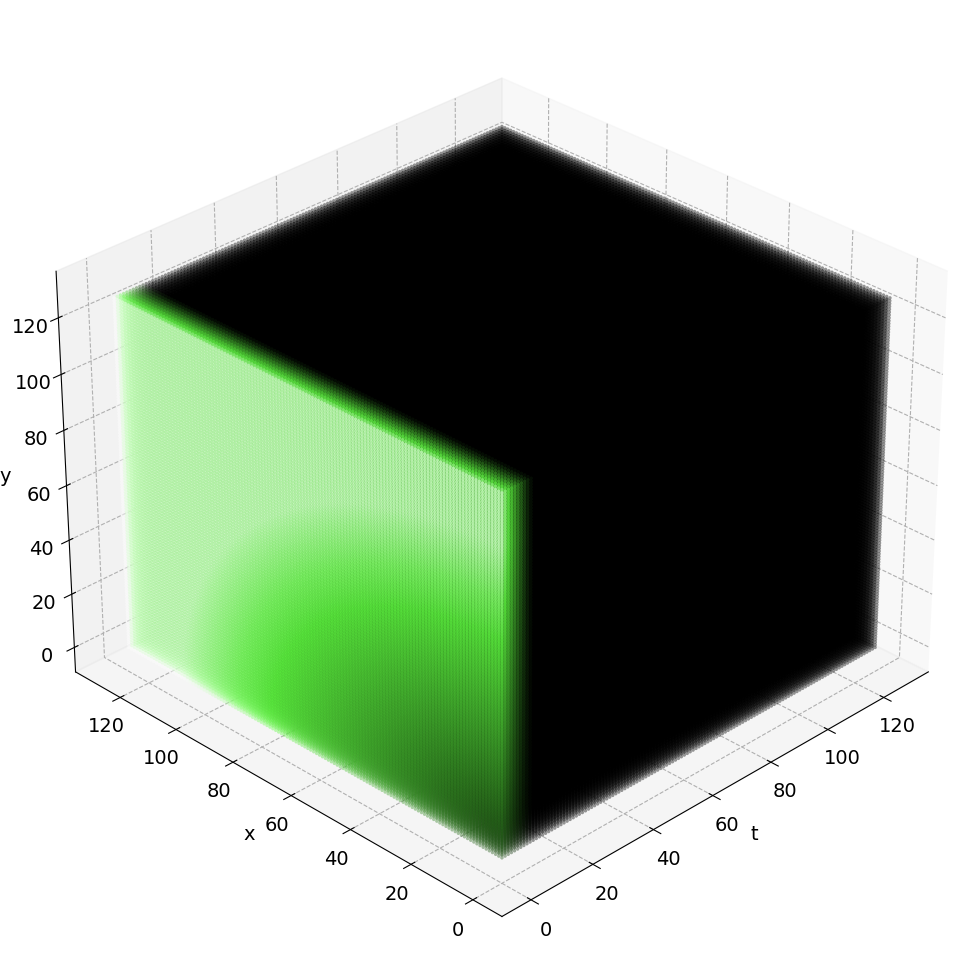

In [18]:
vidshow(W[:128, :128, :128], alpha=0.4, grid=True, dpi=100)